# Strong Lens Transient Dataset


In [1]:
import os
import pickle
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM
from lenstronomy.Cosmo.lens_cosmo import LensCosmo
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Data.psf import PSF
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
from lenstronomy.PointSource.point_source import PointSource
from lenstronomy.Util import kernel_util, image_util
from scipy.signal import fftconvolve
from tqdm import tqdm

# Output directory for arrays and diagnostic figures.
output_dir = './data'
os.makedirs(output_dir, exist_ok=True)

# Flat ΛCDM cosmology (Planck 2018) used by LensCosmo for distance calculations.
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315)

## Lens Configuration Setup


In [2]:
def generate_random_lens_config(num_samples=1000, img_size=240, pixel_scale=0.05):
    """Sample lensing configurations with reduced free parameters for SBI training.

    Free physics parameters (11):
        z_source, 3 halo masses, 6 lens ellipticities (e1/e2 per lens),
        transient_flux_frac.
    Fixed observation parameters (3):
        psf_fwhm, background, exp_time — set to HST ACS/WFC F814W values.
    Everything else is fixed or deterministically derived from the free params.

    Flux calibration — HST ACS/WFC F814W (Sirianni et al. 2005):
        - Zero point: 25.94 AB mag
        - Sky brightness: ~22.1 mag/arcsec^2 (low zodiacal, ACS ISR 2022-01)
        - Read noise: 4 e- (ACS/WFC)
        - Pixel scale: 0.05 arcsec (ACS/WFC native)

    lenstronomy's ImageModel returns pixel values in e-/s/pixel (surface
    brightness × pixel_scale^2, applied inside Numerics.re_size_convolve).
    """

    configs = []

    # ── Fixed constants ──────────────────────────────────────────────────
    Z_LENS = 0.5
    SHEAR_GAMMA = 0.08
    SHEAR_ANGLE = 0.0
    SAT_FRAC = 0.8          # satellite distance as fraction of theta_E_main
    SAT_ANGLES = [2 * np.pi / 3, 4 * np.pi / 3]  # 120° and 240°

    # Fixed source parameters.
    # amp is surface brightness at R_sersic in lenstronomy's internal units.
    # With pixel_scale=0.05, the total image flux sums to ~40 e-/s
    # => apparent mag ~22 in F814W, typical lensed source (Bolton+08, SLACS).
    SOURCE_AMP = 100.0
    SOURCE_R_SERSIC = 0.15  # arcsec
    SOURCE_N_SERSIC = 2.5
    SOURCE_E1 = 0.0
    SOURCE_E2 = 0.0
    SOURCE_X = 0.05         # arcsec, fixed offset from origin
    SOURCE_Y = 0.05

    # Fixed lens-light constants.
    # LIGHT_AMP_COEFF=25 gives total flux ~140 e-/s at sigma_v=200
    # (R_sersic=0.5, n_sersic=3.8) => mag ~20.6 in F814W.
    # Typical SLACS lens galaxies at z~0.2-0.5 have F814W mag 18-21 (Auger+10).
    # Note: n_sersic=3.8 creates a steep central cusp, so the lens center is
    # much brighter than arcs. This is physically correct; arcsinh display
    # scaling is used in visualisations to show both structures.
    LIGHT_AMP_COEFF = 25.0
    LIGHT_R_SERSIC_COEFF = 0.5
    LIGHT_N_SERSIC = 3.8

    # ── Fixed observation parameters (HST ACS/WFC F814W) ────────────────
    # PSF FWHM: 0.09" typical for ACS/WFC F814W (Windhorst+11).
    OBS_PSF_FWHM = 0.09
    # Exposure time: 1000s (single HST orbit science time).
    OBS_EXP_TIME = 1000.0
    # Background RMS derived from bkg_noise formula:
    #   sky_cps = 10^((25.94-22.1)/2.5) = 34.4 e-/s/arcsec^2
    #   sky_per_pixel = 34.4 * 0.05^2 = 0.086 e-/s/pixel
    #   sigma = sqrt(read_noise^2 + sky_per_pixel * exp_time) / exp_time
    #         = sqrt(16 + 86) / 1000 = 0.0101 e-/s/pixel
    OBS_BACKGROUND = 0.010

    for _ in range(num_samples):
        num_lenses = 3
        config: dict[str, Any] = {'num_lenses': num_lenses}

        # ── FREE: source redshift ────────────────────────────────────────
        z_source = np.random.uniform(1.0, 3.0)
        z_lens = Z_LENS
        config['z_source'] = z_source
        config['z_lens'] = z_lens

        # Helper for converting halo velocity dispersion to angular Einstein radius.
        lens_cosmo = LensCosmo(z_lens=z_lens, z_source=z_source, cosmo=cosmo)

        lens_models, lens_params, lens_light_params = ['SIE'] * num_lenses, [], []

        # ── FREE: halo masses ────────────────────────────────────────────
        sampled_masses = 10 ** np.random.uniform(12.0, 13.0, num_lenses)
        central_idx = int(np.argmax(sampled_masses))
        lens_masses = [float(sampled_masses[central_idx])] + [
            float(mass)
            for idx, mass in enumerate(sampled_masses)
            if idx != central_idx
        ]

        # Anchor the Einstein-scale geometry to the dominant (central) halo.
        central_mass = lens_masses[0]
        central_sigma_v = float(200.0 * (central_mass / 1e12) ** 0.25)
        theta_E_main = float(lens_cosmo.sis_sigma_v2theta_E(central_sigma_v))

        # ── FIXED: lens positions ────────────────────────────────────────
        central_x, central_y = 0.0, 0.0
        satellites = []
        for angle in SAT_ANGLES:
            sat_r = SAT_FRAC * theta_E_main
            sat_x = central_x + sat_r * np.cos(angle)
            sat_y = central_y + sat_r * np.sin(angle)
            satellites.append((float(sat_x), float(sat_y)))

        positions = [(central_x, central_y)] + satellites

        config['placement_summary'] = {
            'central': positions[0],
            'satellite_frac': SAT_FRAC,
            'satellite_angles_deg': [120.0, 240.0],
        }

        # Populate the lenstronomy kwargs for each halo.
        for mass, (center_x, center_y) in zip(lens_masses, positions):
            sigma_v = float(200.0 * (mass / 1e12) ** 0.25)
            theta_E = float(lens_cosmo.sis_sigma_v2theta_E(sigma_v))

            # ── FREE: lens ellipticities ─────────────────────────────────
            e1 = np.random.uniform(-0.2, 0.2)
            e2 = np.random.uniform(-0.2, 0.2)

            lens_params.append({
                'theta_E': theta_E,
                'e1': e1,
                'e2': e2,
                'center_x': center_x,
                'center_y': center_y,
            })

            # ── DERIVED: lens light from mass ────────────────────────────
            sigma_ratio = sigma_v / 200.0
            lens_light_params.append({
                'amp': float(LIGHT_AMP_COEFF * sigma_ratio ** 1.2),
                'R_sersic': float(np.clip(LIGHT_R_SERSIC_COEFF * theta_E, 0.15, 0.9)),
                'n_sersic': LIGHT_N_SERSIC,
                'e1': e1,
                'e2': e2,
                'center_x': center_x,
                'center_y': center_y,
            })

        # ── FIXED: external shear ────────────────────────────────────────
        gamma1 = float(SHEAR_GAMMA * np.cos(2 * SHEAR_ANGLE))
        gamma2 = float(SHEAR_GAMMA * np.sin(2 * SHEAR_ANGLE))
        lens_models.append('SHEAR')
        lens_params.append({'gamma1': gamma1, 'gamma2': gamma2})

        config['lens_models'] = lens_models
        config['lens_params'] = lens_params
        config['lens_light_params'] = lens_light_params
        config['lens_masses'] = lens_masses

        # ── FIXED: source parameters ─────────────────────────────────────
        config['source_params'] = [{
            'amp': SOURCE_AMP,
            'R_sersic': SOURCE_R_SERSIC,
            'n_sersic': SOURCE_N_SERSIC,
            'e1': SOURCE_E1,
            'e2': SOURCE_E2,
            'center_x': SOURCE_X,
            'center_y': SOURCE_Y,
        }]

        # ── FREE: transient flux fraction ────────────────────────────────
        config['transient_flux_frac'] = float(np.random.uniform(0.05, 0.15))

        # Fixed observation parameters.
        config['psf_fwhm'] = OBS_PSF_FWHM
        config['background'] = OBS_BACKGROUND
        config['exp_time'] = OBS_EXP_TIME
        config['num_point_sources'] = 1

        configs.append(config)

    return configs

## Critical Curve Search

Function to search for pixels with mu > 20 to locate critical curves.


In [3]:
def find_critical_curve_region(lens_model, lens_params, grid_size=50, search_radius=3.0):
    """Return (x, y) samples where the magnification exceeds the chosen threshold."""

    coords = np.linspace(-search_radius, search_radius, grid_size)
    xx, yy = np.meshgrid(coords, coords)

    try:
        mag = np.abs(lens_model.magnification(xx, yy, lens_params))
    except Exception:
        mag = np.zeros_like(xx)

    mag = np.nan_to_num(mag, nan=0.0, posinf=0.0, neginf=0.0)
    mask = mag > 20
    candidate_points = list(zip(xx[mask], yy[mask]))

    if candidate_points:
        return candidate_points

    # Fallback: sample uniformly along the primary Einstein ring if nothing exceeded the threshold.
    theta_E = lens_params[0]['theta_E']
    center_x = lens_params[0]['center_x']
    center_y = lens_params[0]['center_y']
    angles = np.linspace(0, 2 * np.pi, 20)
    return [
        (center_x + theta_E * np.cos(angle), center_y + theta_E * np.sin(angle))
        for angle in angles
    ]


## Transient Parameterization

Sample source-plane transients near the caustic so their lensed images appear along the critical curve.


In [4]:
def inject_point_sources(config, critical_curve_points, lens_model):
    """Place source-plane transients near the caustic with sampled flux.

    The transient position is deterministically derived from the lens model
    (median caustic point + fixed offset), so it is not a free parameter.
    The transient flux fraction is a free parameter stored in config.
    """

    # Map critical-curve image coordinates to source-plane caustic coordinates.
    pts = np.array(critical_curve_points)
    beta_x, beta_y = lens_model.ray_shooting(pts[:, 0], pts[:, 1], config['lens_params'])
    finite_mask = np.isfinite(beta_x) & np.isfinite(beta_y)
    caustic_points = list(zip(beta_x[finite_mask], beta_y[finite_mask]))

    # Fallback: if the magnification search failed, reuse the source center.
    if not caustic_points:
        source = config['source_params'][0]
        caustic_points.append((source['center_x'], source['center_y']))

    point_source_params = []
    source_amp = config['source_params'][0]['amp']
    theta_E_main = config['lens_params'][0]['theta_E']
    source_offset_scale = max(0.01, 0.05 * theta_E_main)

    # ── FREE: transient flux fraction (sampled in generate_random_lens_config) ──
    transient_flux_frac = config['transient_flux_frac']

    for _ in range(config['num_point_sources']):
        # Use median caustic point for deterministic placement.
        caustic_arr = np.array(caustic_points)
        base_beta_x = float(np.median(caustic_arr[:, 0]))
        base_beta_y = float(np.median(caustic_arr[:, 1]))

        # Fixed offset to avoid sitting exactly on the caustic.
        offset_x = 0.5 * source_offset_scale
        offset_y = 0.0

        flux = source_amp * transient_flux_frac

        point_source_params.append({
            'ra_source': base_beta_x + offset_x,
            'dec_source': base_beta_y + offset_y,
            'point_amp': flux,
        })

    return point_source_params

## Image Rendering

Render clean and transient-contaminated images while keeping the noise realization consistent between them.



In [5]:
def generate_noiseless_lens_image_pair(config, pixel_scale=0.05, img_size=240):
    """Render matched noiseless, unconvolved clean/anomalous images."""

    numpix = img_size
    kwargs_data = {
        'background_rms': config['background'],
        'exposure_time': config['exp_time'],
        'ra_at_xy_0': -(numpix - 1) / 2 * pixel_scale,
        'dec_at_xy_0': -(numpix - 1) / 2 * pixel_scale,
        'transform_pix2angle': np.array([[pixel_scale, 0], [0, pixel_scale]]),
        'image_data': np.zeros((numpix, numpix)),
    }
    data_class = ImageData(**kwargs_data)

    # No PSF convolution for the noiseless rendering.
    psf_class = PSF(psf_type='NONE')

    lens_model_class = LensModel(lens_model_list=config['lens_models'])
    source_model_class = LightModel(light_model_list=['SERSIC_ELLIPSE'])
    lens_light_model_class = LightModel(light_model_list=['SERSIC_ELLIPSE'] * config['num_lenses'])

    image_model = ImageModel(
        data_class=data_class,
        psf_class=psf_class,
        lens_model_class=lens_model_class,
        source_model_class=source_model_class,
        lens_light_model_class=lens_light_model_class,
    )
    base_image = image_model.image(
        kwargs_lens=config['lens_params'],
        kwargs_source=config['source_params'],
        kwargs_lens_light=config['lens_light_params'],
    )

    # Render transient point sources separately (unconvolved).
    critical_curve_points = find_critical_curve_region(lens_model_class, config['lens_params'])
    point_source_params = inject_point_sources(config, critical_curve_points, lens_model_class)

    image_positions = []
    if point_source_params:
        point_source_class = PointSource(
            point_source_type_list=['SOURCE_POSITION'] * len(point_source_params),
            fixed_magnification_list=[False] * len(point_source_params),
        )
        ps_image_model = ImageModel(
            data_class=data_class,
            psf_class=psf_class,
            lens_model_class=lens_model_class,
            point_source_class=point_source_class,
        )
        ps_image = ps_image_model.point_source(
            kwargs_lens=config['lens_params'],
            kwargs_ps=point_source_params,
            unconvolved=True,
        )

        lens_solver = LensEquationSolver(lens_model_class)
        for ps in point_source_params:
            try:
                x_img, y_img = lens_solver.image_position_from_source(
                    sourcePos_x=ps['ra_source'],
                    sourcePos_y=ps['dec_source'],
                    kwargs_lens=config['lens_params'],
                    search_window=5,
                )
            except Exception:
                continue

            for x_val, y_val in zip(np.atleast_1d(x_img), np.atleast_1d(y_img)):
                image_positions.append((float(x_val), float(y_val)))
    else:
        ps_image = np.zeros_like(base_image)

    return base_image, ps_image, point_source_params, image_positions


def add_observation_noise(base_image, ps_image, config, pixel_scale=0.05):
    """Apply PSF convolution and realistic noise to produce matched clean/anomalous images.

    Noise model (via lenstronomy utilities):
        - Poisson noise: sigma_i = sqrt(|image_i| / exposure_time)  (signal-dependent)
        - Gaussian background: sigma = background_rms               (uniform sky noise)
    Both noise arrays are shared between clean and anomalous images so that
    the difference isolates the transient signal.
    """

    # PSF convolution.
    kernel_size = max(int(config['psf_fwhm'] / pixel_scale * 3), 15)
    if kernel_size % 2 == 0:
        kernel_size += 1
    kernel = kernel_util.kernel_gaussian(kernel_size, pixel_scale, config['psf_fwhm'])
    base_convolved = fftconvolve(base_image, kernel, mode='same')
    ps_convolved = fftconvolve(ps_image, kernel, mode='same')

    # Shared noise realization (Poisson + Gaussian background).
    poisson = image_util.add_poisson(base_convolved, exp_time=config['exp_time'])
    background = image_util.add_background(base_convolved, sigma_bkd=config['background'])

    clean_image = base_convolved + poisson + background
    anomalous_image = clean_image + ps_convolved

    return clean_image, anomalous_image

## Batch Generation


In [6]:
num_samples = 1000  # Total number of lens systems to synthesize (reduced from 10k for testing).
configs = generate_random_lens_config(num_samples=num_samples)

base_images = []
ps_images = []
metadata = []

for index, config in enumerate(tqdm(configs, desc="Rendering", leave=False)):
    try:
        base_img, ps_img, ps_params, ps_image_pos = generate_noiseless_lens_image_pair(config)

        base_images.append(base_img)
        ps_images.append(ps_img)
        metadata.append({
            'index': index,
            'num_lenses': config['num_lenses'],
            'z_source': config['z_source'],
            'z_lens': config['z_lens'],
            'lens_masses': config['lens_masses'],
            'lens_models': config['lens_models'],
            'lens_params': config['lens_params'],
            'lens_light_params': config['lens_light_params'],
            'source_params': config['source_params'],
            'transient_flux_frac': config['transient_flux_frac'],
            'num_point_sources': config['num_point_sources'],
            'point_source_params': ps_params,
            'transient_image_positions': ps_image_pos,
            'psf_fwhm': config['psf_fwhm'],
            'background': config['background'],
            'exp_time': config['exp_time'],
            # Collect the 11 free physics parameters for SBI convenience.
            'free_params': {
                'z_source': config['z_source'],
                'log10_mass_1': float(np.log10(config['lens_masses'][0])),
                'log10_mass_2': float(np.log10(config['lens_masses'][1])),
                'log10_mass_3': float(np.log10(config['lens_masses'][2])),
                'e1_lens_1': config['lens_params'][0]['e1'],
                'e2_lens_1': config['lens_params'][0]['e2'],
                'e1_lens_2': config['lens_params'][1]['e1'],
                'e2_lens_2': config['lens_params'][1]['e2'],
                'e1_lens_3': config['lens_params'][2]['e1'],
                'e2_lens_3': config['lens_params'][2]['e2'],
                'transient_flux_frac': config['transient_flux_frac'],
            },
        })
    except Exception as exc:
        # Preserve indexing by inserting empty placeholders if lenstronomy fails.
        base_images.append(np.zeros((240, 240)))
        ps_images.append(np.zeros((240, 240)))
        metadata.append({'index': index, 'error': str(exc)})

## Noiseless Visualization

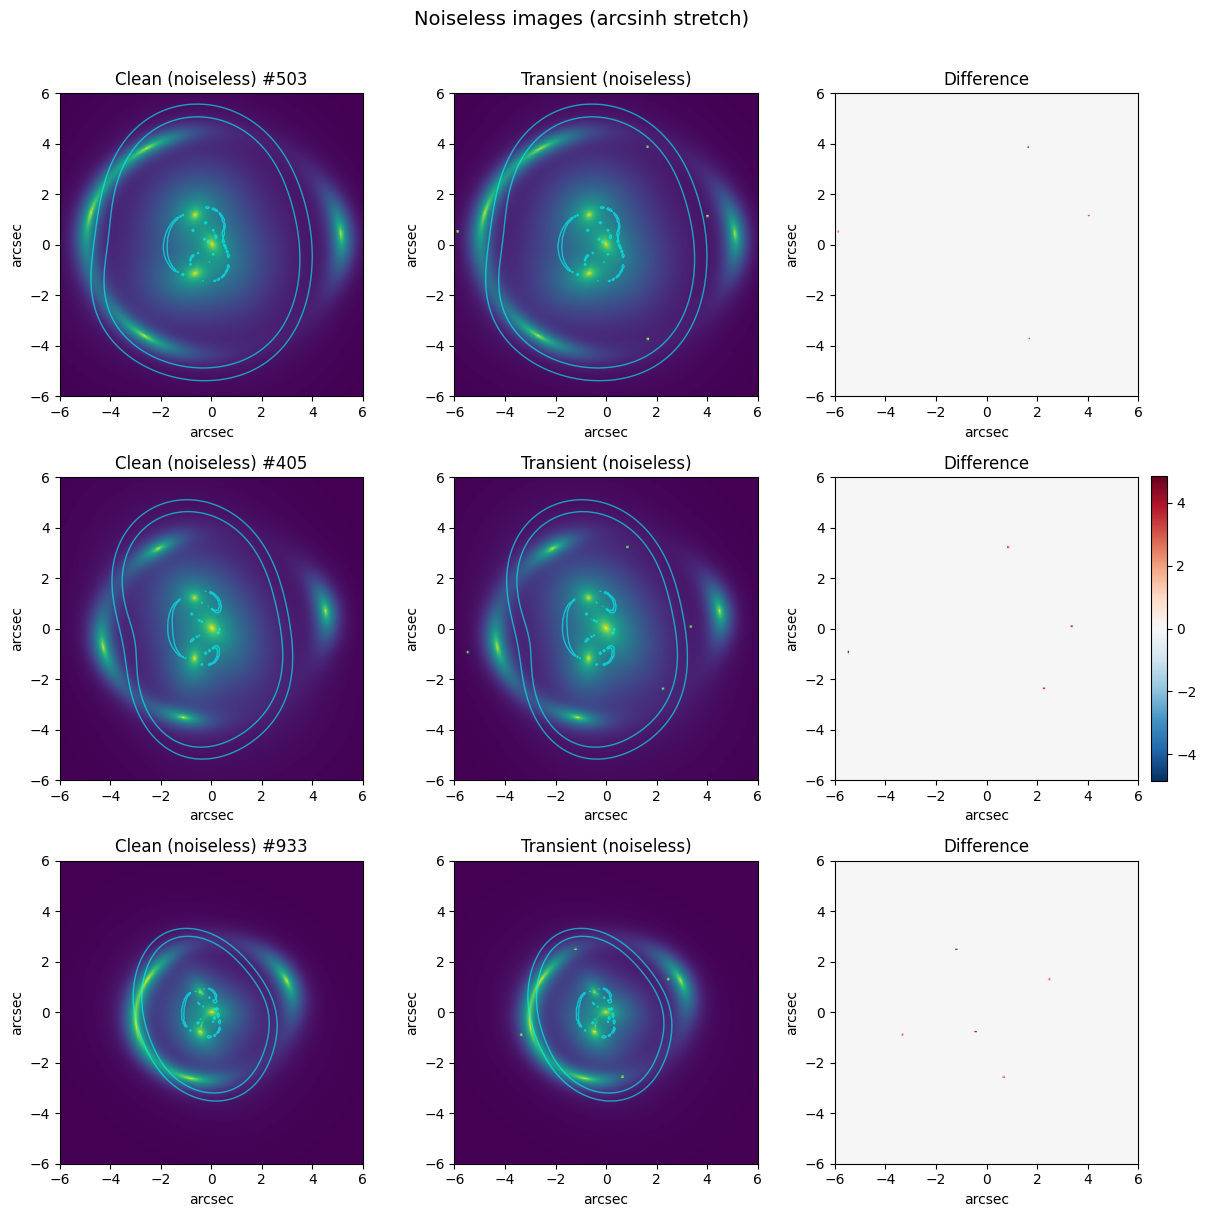

In [7]:
def plot_image_triplets(clean_list, anomalous_list, metadata, sample_indices,
                        suptitle, clean_label='Clean', anom_label='Transient',
                        pixel_scale=0.05):
    """Plot a 3x3 grid of clean / anomalous / difference images with magnification contours."""
    img_size = clean_list[0].shape[0]
    ra0 = -(img_size - 1) / 2 * pixel_scale
    dec0 = -(img_size - 1) / 2 * pixel_scale
    extent = [
        ra0 - pixel_scale / 2,
        ra0 + (img_size - 1) * pixel_scale + pixel_scale / 2,
        dec0 - pixel_scale / 2,
        dec0 + (img_size - 1) * pixel_scale + pixel_scale / 2,
    ]
    x_coords = ra0 + np.arange(img_size) * pixel_scale
    y_coords = dec0 + np.arange(img_size) * pixel_scale
    xx, yy = np.meshgrid(x_coords, y_coords)

    SOFTENING = 0.01  # e-/s, ~1x background_rms

    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    mag_maps = {}
    for row, idx in enumerate(sample_indices):
        meta = metadata[idx]
        lens_model = LensModel(lens_model_list=meta['lens_models'])

        # Vectorized magnification map computation.
        try:
            mag_map = np.abs(lens_model.magnification(xx, yy, meta['lens_params']))
        except Exception:
            mag_map = np.zeros_like(xx)
        mag_map = np.nan_to_num(mag_map, nan=0.0, posinf=0.0, neginf=0.0)
        mag_maps[idx] = mag_map

        clean = clean_list[idx]
        anomalous = anomalous_list[idx]
        diff = anomalous - clean
        diff_scale = np.max(np.abs(diff)) or 1.0

        axes[row, 0].imshow(np.arcsinh(clean / SOFTENING), cmap='viridis', origin='lower', extent=extent)
        axes[row, 0].contour(xx, yy, mag_map, levels=[20], colors='cyan', linewidths=1, alpha=0.6)
        axes[row, 0].set_title(f'{clean_label} #{idx}')

        axes[row, 1].imshow(np.arcsinh(anomalous / SOFTENING), cmap='viridis', origin='lower', extent=extent)
        axes[row, 1].contour(xx, yy, mag_map, levels=[20], colors='cyan', linewidths=1, alpha=0.6)
        axes[row, 1].set_title(f'{anom_label}')

        im = axes[row, 2].imshow(
            diff, cmap='RdBu_r', origin='lower', extent=extent,
            vmin=-diff_scale, vmax=diff_scale,
        )
        axes[row, 2].set_title('Difference')

        for col in range(3):
            axes[row, col].set_xlabel('arcsec')
            axes[row, col].set_ylabel('arcsec')

    fig.suptitle(suptitle, fontsize=14, y=1.01)
    fig.tight_layout()
    plt.colorbar(im, ax=axes[:, 2], fraction=0.046, pad=0.04)
    plt.show()
    return mag_maps


sample_indices = np.random.choice(len(base_images), 3, replace=False)
noiseless_anomalous = [b + p for b, p in zip(base_images, ps_images)]
cached_mag_maps = plot_image_triplets(
    base_images, noiseless_anomalous, metadata, sample_indices,
    suptitle='Noiseless images (arcsinh stretch)',
    clean_label='Clean (noiseless)', anom_label='Transient (noiseless)',
)

## Noise Application

Apply observation noise to the noiseless image pairs.

In [8]:
clean_images = []
anomalous_images = []

for base_img, ps_img, config in zip(base_images, ps_images, configs):
    clean_img, anom_img = add_observation_noise(base_img, ps_img, config)
    clean_images.append(clean_img)
    anomalous_images.append(anom_img)

## Persistence

Convert the in-memory lists to arrays and persist images plus metadata for later analysis.



In [9]:
clean_images_array = np.array(clean_images)
anomalous_images_array = np.array(anomalous_images)

np.save(f'{output_dir}/clean_images.npy', clean_images_array)
np.save(f'{output_dir}/anomalous_images.npy', anomalous_images_array)
with open(f'{output_dir}/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)



## Visualization



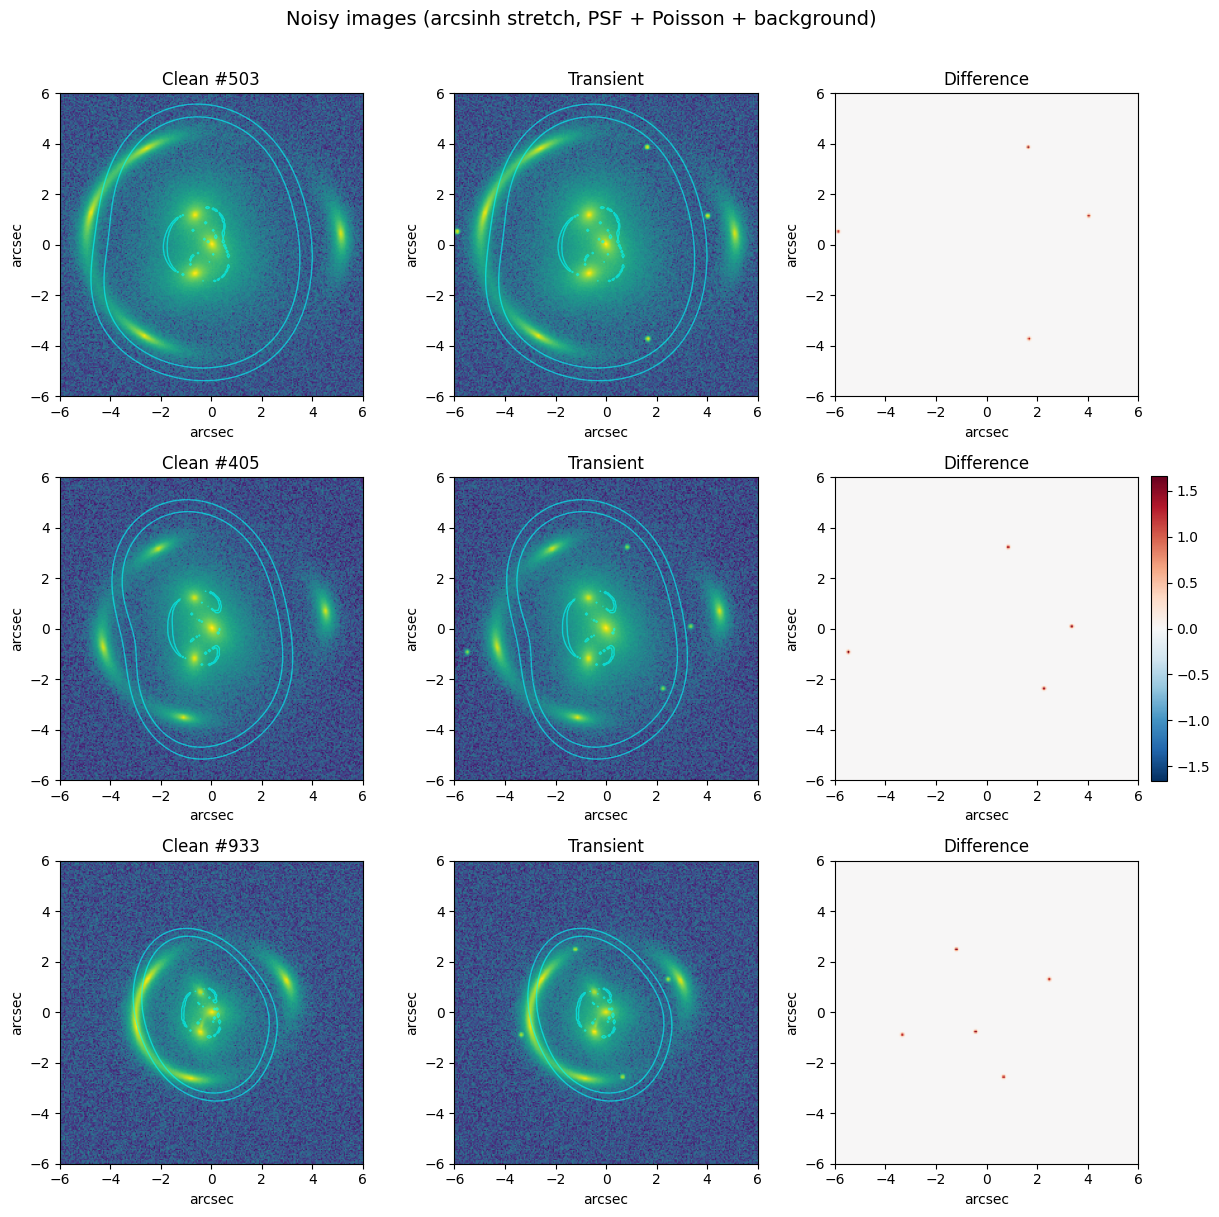

{np.int64(503): array([[2.49831867, 2.51545026, 2.53287268, ..., 2.25047591, 2.23661262,
         2.22296987],
        [2.51407779, 2.5316395 , 2.54952848, ..., 2.25923926, 2.24516538,
         2.23127187],
        [2.53004369, 2.54812062, 2.56647304, ..., 2.26808006, 2.2537405 ,
         2.23960973],
        ...,
        [2.41473202, 2.43287719, 2.45145775, ..., 2.20186903, 2.18959859,
         2.17753884],
        [2.403458  , 2.42127621, 2.43946677, ..., 2.19351578, 2.18142437,
         2.16958454],
        [2.39231737, 2.40977114, 2.42761452, ..., 2.18520519, 2.17334613,
         2.16169684]], shape=(240, 240)),
 np.int64(405): array([[1.88403502, 1.89364805, 1.90338771, ..., 2.0102609 , 1.99967128,
         1.98926922],
        [1.88881205, 1.89854184, 1.90843334, ..., 2.01558151, 2.00483466,
         1.99429877],
        [1.89361911, 1.90346892, 1.91352768, ..., 2.02091811, 2.01003213,
         1.99932719],
        ...,
        [2.23970361, 2.25548704, 2.27155864, ..., 1.78998679

In [10]:
plot_image_triplets(
    clean_images, anomalous_images, metadata, sample_indices,
    suptitle='Noisy images (arcsinh stretch, PSF + Poisson + background)',
)

## Summary Statistics

Print a compact set of descriptive statistics for the synthesized dataset.



In [11]:
total_pairs = len(clean_images)
print(f'Total image pairs: {total_pairs}')

if clean_images_array.size:
    print(f'Image shape: {clean_images_array.shape[1:]} pixels')


def _safe_stats(values):
    """Return mean, std, min, max for iterable values while ignoring Nones."""
    filtered = [v for v in values if v is not None]
    if not filtered:
        return None
    arr = np.array(filtered, dtype=float)
    return arr.mean(), arr.std(), arr.min(), arr.max()


# ── Free parameter statistics ────────────────────────────────────────
print('\n── Free Physics Parameters (11) ──')

z_source_stats = _safe_stats([m.get('z_source') for m in metadata if 'error' not in m])
if z_source_stats:
    mean, std, vmin, vmax = z_source_stats
    print(f'  z_source:       mean={mean:.3f}, std={std:.3f}, range=[{vmin:.3f}, {vmax:.3f}]')

lens_mass_stats = _safe_stats(
    mass for m in metadata if 'error' not in m for mass in m.get('lens_masses', [])
)
if lens_mass_stats:
    mean, std, vmin, vmax = lens_mass_stats
    print(f'  lens mass (Msun): mean={mean:.2e}, std={std:.2e}, range=[{vmin:.2e}, {vmax:.2e}]')

theta_e_stats = _safe_stats(
    lp.get('theta_E') for m in metadata if 'error' not in m for lp in m.get('lens_params', []) if 'theta_E' in lp
)
if theta_e_stats:
    mean, std, vmin, vmax = theta_e_stats
    print(f'  theta_E (arcsec): mean={mean:.3f}, std={std:.3f}, range=[{vmin:.3f}, {vmax:.3f}]')

e1_stats = _safe_stats(
    lp.get('e1') for m in metadata if 'error' not in m for lp in m.get('lens_params', []) if 'e1' in lp
)
if e1_stats:
    mean, std, vmin, vmax = e1_stats
    print(f'  e1 (all lenses): mean={mean:.3f}, std={std:.3f}, range=[{vmin:.3f}, {vmax:.3f}]')

e2_stats = _safe_stats(
    lp.get('e2') for m in metadata if 'error' not in m for lp in m.get('lens_params', []) if 'e2' in lp
)
if e2_stats:
    mean, std, vmin, vmax = e2_stats
    print(f'  e2 (all lenses): mean={mean:.3f}, std={std:.3f}, range=[{vmin:.3f}, {vmax:.3f}]')

flux_frac_stats = _safe_stats([m.get('transient_flux_frac') for m in metadata if 'error' not in m])
if flux_frac_stats:
    mean, std, vmin, vmax = flux_frac_stats
    print(f'  transient_flux_frac: mean={mean:.3f}, std={std:.3f}, range=[{vmin:.3f}, {vmax:.3f}]')

# ── Fixed parameter confirmation ─────────────────────────────────────
print('\n── Fixed Parameters ──')
z_lens_vals = [m.get('z_lens') for m in metadata if 'error' not in m and m.get('z_lens') is not None]
if z_lens_vals:
    print(f'  z_lens:           {z_lens_vals[0]} (std={np.std(z_lens_vals):.1e})')
print(f'  Shear gamma:      0.08 (angle=0.0)')
print(f'  Source position:  (0.05, 0.05) arcsec')
print(f'  Source amp:       100.0 (mag ~22 in F814W)')
print(f'  Lens light amp:   25.0 * (sigma_v/200)^1.2 (mag ~20.6 at sigma_v=200)')

# ── Fixed observation parameters ─────────────────────────────────────
print('\n── Fixed Observation Parameters ──')
print(f'  PSF FWHM:         0.09 arcsec (ACS/WFC F814W)')
print(f'  Background RMS:   0.010 e-/s/pixel (from bkg_noise formula)')
print(f'  Exposure time:    1000 s (single HST orbit)')

errors = sum(1 for m in metadata if 'error' in m)
if errors:
    print(f'\nFailed configurations: {errors}/{total_pairs}')

Total image pairs: 1000
Image shape: (240, 240) pixels

── Free Physics Parameters (11) ──
  z_source:       mean=1.980, std=0.579, range=[1.002, 2.998]
  lens mass (Msun): mean=3.84e+12, std=2.45e+12, range=[1.00e+12, 9.98e+12]
  theta_E (arcsec): mean=1.310, std=0.460, range=[0.510, 2.518]
  e1 (all lenses): mean=-0.003, std=0.118, range=[-0.200, 0.200]
  e2 (all lenses): mean=-0.001, std=0.115, range=[-0.200, 0.200]
  transient_flux_frac: mean=0.101, std=0.029, range=[0.050, 0.150]

── Fixed Parameters ──
  z_lens:           0.5 (std=0.0e+00)
  Shear gamma:      0.08 (angle=0.0)
  Source position:  (0.05, 0.05) arcsec
  Source amp:       100.0 (mag ~22 in F814W)
  Lens light amp:   25.0 * (sigma_v/200)^1.2 (mag ~20.6 at sigma_v=200)

── Fixed Observation Parameters ──
  PSF FWHM:         0.09 arcsec (ACS/WFC F814W)
  Background RMS:   0.010 e-/s/pixel (from bkg_noise formula)
  Exposure time:    1000 s (single HST orbit)


## Dataset Overview (Reduced Parameter Space)

This simulator uses an **11-dimensional free parameter space** designed for tractable SBI training.

All flux units are e-/s/pixel, calibrated to **HST ACS/WFC F814W** (Sirianni et al. 2005):
- Zero point: 25.94 AB mag
- Sky brightness: ~22.1 mag/arcsec² (low zodiacal background)
- Read noise: 4 e-
- Pixel scale: 0.05 arcsec (ACS/WFC native)

### Free Physics Parameters (11)

| # | Parameter | Distribution | Range |
|---|-----------|-------------|-------|
| 1 | z_source | Uniform | [1.0, 3.0] |
| 2 | log₁₀(M_central) | Uniform | [12, 13] (M☉) |
| 3 | log₁₀(M_sat1) | Uniform | [12, 13] (M☉) |
| 4 | log₁₀(M_sat2) | Uniform | [12, 13] (M☉) |
| 5 | e1 (central lens) | Uniform | [-0.2, 0.2] |
| 6 | e2 (central lens) | Uniform | [-0.2, 0.2] |
| 7 | e1 (satellite 1) | Uniform | [-0.2, 0.2] |
| 8 | e2 (satellite 1) | Uniform | [-0.2, 0.2] |
| 9 | e1 (satellite 2) | Uniform | [-0.2, 0.2] |
| 10 | e2 (satellite 2) | Uniform | [-0.2, 0.2] |
| 11 | transient_flux_frac | Uniform | [0.05, 0.15] |

### Fixed Parameters

| Parameter | Value | Notes |
|-----------|-------|-------|
| z_lens | 0.5 | Typical cluster lens redshift |
| Central lens position | (0, 0) | Origin of coordinate system |
| Satellite positions | 0.8 × θ_E at 120°, 240° | Symmetric triangular arrangement |
| External shear γ | 0.08, angle = 0° | Midpoint of previous prior |
| Source position | (0.05, 0.05) arcsec | Fixed offset, always inside Einstein ring |
| Source amplitude | 100.0 (mag ~22) | Typical lensed source in F814W (Bolton+08) |
| Source R_sersic | 0.15 arcsec | Compact background galaxy |
| Source n_sersic | 2.5 | Intermediate disk/bulge profile |
| Source e1, e2 | 0.0 | Circular source |
| Lens light amp | 25 × (σ_v/200)^1.2 | ~mag 20.6 at σ_v=200; SLACS lenses: F814W 18–21 (Auger+10) |
| Lens light R_sersic | 0.5 × θ_E (clipped to [0.15, 0.9]) | Deterministic from mass |
| Lens light n_sersic | 3.8 | Typical massive elliptical |

### Fixed Observation Parameters (HST ACS/WFC F814W)

| Parameter | Value | Physical basis |
|-----------|-------|----------------|
| PSF FWHM | 0.09 arcsec | ACS/WFC F814W typical (Windhorst+11) |
| Background RMS | 0.010 e-/s/pixel | bkg_noise(read_noise=4, sky=22.1 mag, 0.05"/pix, T=1000s) |
| Exposure time | 1000 s | Single HST orbit science time |

### Simulation Details
- **Lens ensemble**: 3 SIE halos (most massive at center, 2 satellites at fixed angular offsets) + 1 fixed external shear. Halo masses map to velocity dispersions via Faber–Jackson and yield Einstein radii in a Flat ΛCDM (Planck 2018) cosmology.
- **Lens galaxy light**: Each halo carries a co-aligned Sérsic profile with amplitude and size deterministically derived from the halo mass. The n=3.8 profile creates a steep central cusp, so the lens center is much brighter than arc structures — this is physically correct.
- **Background source**: Fixed circular Sérsic profile at (0.05, 0.05) arcsec. Different lensing potentials produce different arc morphologies from the same source.
- **Transient injection**: A single source-plane point emitter placed deterministically near the median caustic point. Flux is sampled as a fraction of the source amplitude from U(0.05, 0.15).
- **Image formation**: lenstronomy ray-traces onto a 240×240 grid (0.05 arcsec/pixel). Noiseless images are rendered without PSF. Observation noise is then applied: Gaussian PSF convolution via `fftconvolve`, signal-dependent Poisson noise via `image_util.add_poisson()`, and Gaussian background noise via `image_util.add_background()`. Clean and transient images share the same noise realization so that the difference isolates the transient signal.
- **Visualisation**: Images are displayed with arcsinh stretch (standard in astronomical imaging, e.g. SDSS/HSC/Rubin) to reveal faint arc structures alongside the bright lens galaxy centre.
- **Metadata**: Each sample stores all parameters plus a `free_params` dict with the 11 SBI-relevant values for convenient downstream extraction.